In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import intake
import glob
import sys
import os
sys.path.append(os.path.dirname('../workflow'))
from workflow.scripts.utils import calc_implausibility_obs
import pandas as pd
from dask.distributed import Client, LocalCluster

In [2]:
cluster = LocalCluster(n_workers=2, threads_per_worker=1, memory_limit='8GB')
client = Client(cluster)

2024-09-21 19:11:12,066 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:44649' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('mean_chunk-5a5c2cd7f0c4816a74374d37d246a463', 198, 0, 0), ('mean_chunk-26549d196735f81e777dabe958587fe0', 352, 0, 0), ('mean_chunk-5a5c2cd7f0c4816a74374d37d246a463', 206, 0, 0), ('getitem-c2987bef693c30d392ca1c3cbabc0688', 9, 0, 0), ('mean_chunk-5a5c2cd7f0c4816a74374d37d246a463', 195, 0, 0), ('mean_chunk-5a5c2cd7f0c4816a74374d37d246a463', 240, 0, 0), ('concatenate-open_dataset-getitem-423aad2b4b90ef20ae053f044b1b1a11', 233, 0, 0), ('mean_chunk-5a5c2cd7f0c4816a74374d37d246a463', 243, 0, 0), ('mean_chunk-5a5c2cd7f0c4816a74374d37d246a463', 242, 0, 0), ('getitem-c2987bef693c30d392ca1c3cbabc0688', 12, 0, 0), ('getitem-c2987bef693c30d392ca1c3cbabc0688', 6, 0, 0), ('mean_combine-partial-c897316634deba35091c119d52ec3493', 0, 0, 0), ('mean_chunk-5a5c2cd7f0c4816a74374d37d246a463', 192, 0, 0), ('mean_combine

In [3]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 2
Total threads: 2,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42205,Workers: 2
Dashboard: /proxy/8787/status,Total threads: 2
Started: Just now,Total memory: 14.90 GiB
Comm: tcp://127.0.0.1:43221,Total threads: 1
Dashboard: /proxy/40933/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:44973,


In [4]:
def read_obs(path):
    ''' Read in the IASI satellite observations
    returns:
        obs: xr.Dataset fully spatially and time resolved observational dataset
        obs_tm: time-mean observational dataset'''
    files = sorted(glob.glob(path + '*.nc'))
    obs = xr.open_mfdataset(files, combine='by_coords')
    obs = obs.rename({'latitude': 'lat'})
    obs = obs.rename({'longitude': 'lon'})
    obs_tm = obs.od550dust.mean(dim='time')
    return obs, obs_tm

def convert_lon_to_180(ds):
    ''' Adapted from the eScience notebook templates
    Convert longitude coordinates from 0-360 to -180-180'''
    ds['lon'] = (ds['lon'] + 180) % 360 - 180
    ds = ds.sortby('lon')
    return ds

def global_mean(ds):
    ''' Calculate the global mean of a gridded dataset
    args:
        ds: xr.DataArray or xr.Dataset
    returns:
        xr.DataArray or xr.Dataset: latitude-weighted average of ds
    '''
    weights = np.cos(np.deg2rad(ds.lat))
    return ds.weighted(weights).mean(['lat', 'lon'])

def calc_dod_gradient_lon(ds,lon0=-55,lon1=35,lat_slice=slice(5,35), 
                            longitude_bins=5, differentiate=True):
    ''' Calculate the dust optical depth gradient along the longitude direction
    args:
        ds: xr.Dataset containing the dust optical depth data
        lon0: float, longitude of the western boundary of the region of interest
        lon1: float, longitude of the eastern boundary of the region of interest
        lat_slice: slice object, latitude range of the region of interest
    returns:
        xr.DataArray: dust optical depth gradient along the longitude direction
    '''
    weights = np.cos(np.deg2rad(ds.lat))
    dod = ds
    dod = dod.sel(lat=lat_slice)
    dod = dod.sel(lon=slice(lon0,lon1))
    dod = dod.weighted(weights).mean('lat')
    dod_binned = dod.groupby_bins('lon', longitude_bins).mean(keep_attrs=True)
    lon_bins = [intervall.mid for intervall in dod_binned.lon_bins.values]
    dod_binned['lon_bins'] = lon_bins
    if differentiate:
        dod_grad = dod_binned.compute().differentiate('lon_bins')
    else:
        dod_grad = dod_binned
    # dod = global_mean(dod)
    return dod_grad


import numpy as np
from scipy.stats import t

import numpy as np
from scipy.stats import t

def calculate_CI(data, alpha=0.05, margin_of_error_multiplier=None):
    """
    Calculate the confidence interval of the mean.

    Parameters
    ----------
    data : array-like
        The data from which to calculate the confidence interval.
    alpha : float, optional
        The significance level, by default 0.05.
    margin_of_error_multiplier : float, optional
        The multiplier to apply to the margin of error.

    Returns
    -------
    tuple
        The lower and upper bounds of the confidence interval, and the margin of error multiplied by the standard deviation.
    """
    sample_mean = np.mean(data)
    sample_std = np.std(data, ddof=1)
    sample_size = len(data)
    
    # Calculate the critical value
    t_critical = t.ppf(1 - alpha/2, df=sample_size-1)
    
    # Calculate the margin of error
    if margin_of_error_multiplier is not None:
        margin_of_error = t_critical * (sample_std / np.sqrt(sample_size))
        margin_of_error *= margin_of_error_multiplier
    else:
        margin_of_error = t_critical * (sample_std / np.sqrt(sample_size))
    
    # Calculate the lower and upper bounds
    lower_bound = sample_mean - margin_of_error
    upper_bound = sample_mean + margin_of_error
    
    return lower_bound, upper_bound, margin_of_error * sample_std



In [5]:
latmin= -6
latmax= 34
lonmin= -66
lonmax= -16

obs, obs_tm = read_obs('/mnt/keyclim-ns9252k-volume-for-ns9560k-datalake/ESGF/rawdata/obs/Tier2/IASI_ULB.v9.DN/renamed/')
obsym = obs.sel(time=slice('2008',None)).resample(time='YE').mean()
obs_natl = global_mean(obsym.sel(lat=slice(latmin,latmax),lon=slice(lonmin,lonmax)).compute())


2024-09-21 19:11:12,063 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:44649
Traceback (most recent call last):
  File "/opt/conda/envs/dustysnake/lib/python3.12/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
                 ^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/envs/dustysnake/lib/python3.12/site-packages/tornado/iostream.py", line 1116, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ConnectionResetError: [Errno 104] Connection reset by peer

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/opt/conda/envs/dustysnake/lib/python3.12/site-packages/distributed/worker.py", line 2056, in gather_dep
    response = await get_data_from_worker(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/envs/dustysnake/lib/python3.12/site-packages/distributed/wor

In [6]:
obs_nafr = global_mean(obsym.sel(lat=slice(5,35), lon=slice(-15,35)).compute())

2024-09-21 19:11:52,519 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:43653
Traceback (most recent call last):
  File "/opt/conda/envs/dustysnake/lib/python3.12/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
                 ^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/envs/dustysnake/lib/python3.12/site-packages/tornado/iostream.py", line 1116, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ConnectionResetError: [Errno 104] Connection reset by peer

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/opt/conda/envs/dustysnake/lib/python3.12/site-packages/distributed/worker.py", line 2056, in gather_dep
    response = await get_data_from_worker(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/envs/dustysnake/lib/python3.12/site-packages/distributed/wor

In [10]:
obs_grad = calc_dod_gradient_lon(obsym,lon0=lonmin,lon1=lonmax,longitude_bins=[-65,-55,-45,-35,-25,-15],
                                lat_slice=slice(latmin,latmax), differentiate=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fb37bd49da0>
Traceback (most recent call last):
  File "/opt/conda/envs/dustysnake/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/opt/conda/envs/dustysnake/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2618, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2585, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2113, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: HDF error


In [13]:
dod_binned = obsym.sel(lat=slice(latmin,latmax),lon=slice(lonmin,lonmax))
weights = np.cos(np.deg2rad(dod_binned.lat))
dod_binned = dod_binned.weighted(weights).mean('lat')
dod_binned = dod_binned.groupby_bins('lon', 8).mean(keep_attrs=True)
lon_bins = [intervall.mid for intervall in dod_binned.lon_bins.values]
dod_binned['lon_bins'] = lon_bins



In [14]:
var_obs_grad = obs_grad['od550dust'].std(dim='time')

In [15]:
cat = intake.open_esm_datastore('../catalogues/merge_CMIP6.json')
exp_cat = cat.search(experiment_id='piClim-control', variable_id=['od550dust'],table_id='AERmon')

In [16]:
def pre_process_model_data(ds):
    ds = ds.resample(time='YE').mean()
    ds = convert_lon_to_180(ds)
    ds_natl = global_mean(ds.sel(lat=slice(latmin,latmax),lon=slice(lonmin,lonmax)))
    ds_nafr =global_mean(ds.sel(lat=slice(5,35), lon=slice(-15,35)))
    diff = ds_natl-ds_nafr
    # diff_ano = (diff-diff.mean(dim='time'))
    return diff

def pre_process_model_data_grad(ds):
    ds = ds.resample(time='YE').mean()
    ds = convert_lon_to_180(ds)
    ds_grad = calc_dod_gradient_lon(ds,lon0=-65,lon1=-15,longitude_bins=[-65,-55,-45,-35,-25,-15],
                                    lat_slice =slice(latmin,latmax))
    return ds_grad

def pre_process_model_data_binned(ds):
    ds = ds.resample(time='YE').mean()
    ds = convert_lon_to_180(ds)
    ds_grad = calc_dod_gradient_lon(ds,lon0=-65,lon1=-15,longitude_bins=[-65,-55,-45,-35,-25,-15], differentiate=False,
                                    lat_slice =slice(latmin,latmax))
    return ds_grad




In [ ]:
grad_model = exp_cat.search(source_id=['CNRM-ESM2-1','UKESM1-0-LL','IPSL-CM6A-LR-INCA','MIROC6','GISS-E2-1-G','NorESM2-LM', 'EC-Earth3-AerChem','GFDL-ESM4','MPI-ESM-1-2-HAM']).to_dataset_dict(cdf_kwargs={'chunks': {'time': 12}},preprocess=pre_process_model_data_grad,skip_on_error=False)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.experiment_id.member_id'


2024-09-21 20:55:22,255 - distributed.client - WARNING - Couldn't gather 60 keys, rescheduling (('concatenate-38f10b4ea0f79a7e750124998e4eb1aa', 4, 0, 0), ('concatenate-07a2110be3b4ff475bee852c6d1e19f0', 2, 8, 0), ('concatenate-38f10b4ea0f79a7e750124998e4eb1aa', 2, 1, 0), ('concatenate-38f10b4ea0f79a7e750124998e4eb1aa', 2, 5, 0), ('concatenate-38f10b4ea0f79a7e750124998e4eb1aa', 2, 3, 0), ('concatenate-38f10b4ea0f79a7e750124998e4eb1aa', 2, 7, 0), ('concatenate-38f10b4ea0f79a7e750124998e4eb1aa', 1, 3, 0), ('concatenate-07a2110be3b4ff475bee852c6d1e19f0', 0, 4, 0), ('concatenate-07a2110be3b4ff475bee852c6d1e19f0', 3, 9, 0), ('concatenate-38f10b4ea0f79a7e750124998e4eb1aa', 1, 5, 0), ('concatenate-07a2110be3b4ff475bee852c6d1e19f0', 2, 3, 0), ('concatenate-07a2110be3b4ff475bee852c6d1e19f0', 4, 8, 0), ('concatenate-07a2110be3b4ff475bee852c6d1e19f0', 1, 1, 0), ('concatenate-38f10b4ea0f79a7e750124998e4eb1aa', 1, 9, 0), ('concatenate-07a2110be3b4ff475bee852c6d1e19f0', 2, 1, 0), ('concatenate-38f10

In [ ]:
binned_model = exp_cat.search(source_id=['CNRM-ESM2-1','UKESM1-0-LL','IPSL-CM6A-LR-INCA','MIROC6','GISS-E2-1-G','NorESM2-LM', 'EC-Earth3-AerChem','GFDL-ESM4','MPI-ESM-1-2-HAM']).to_dataset_dict(cdf_kwargs={'chunks': {'time': 12}},preprocess=pre_process_model_data_binned,skip_on_error=False)

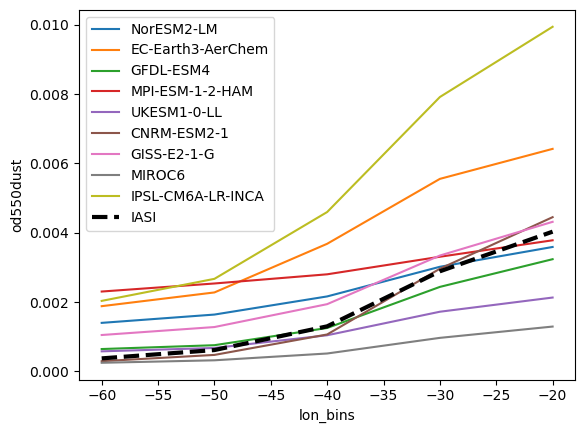

In [15]:
fig,ax = plt.subplots()
grad_model['RFMIP.NCC.NorESM2-LM.piClim-control.AERmon.gn'].isel(member_id=1)['od550dust'].mean(dim='time').plot(ax=ax, label='NorESM2-LM')
grad_model['RFMIP.EC-Earth-Consortium.EC-Earth3-AerChem.piClim-control.AERmon.gn'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='EC-Earth3-AerChem')
grad_model['AerChemMIP.NOAA-GFDL.GFDL-ESM4.piClim-control.AERmon.gr1'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='GFDL-ESM4')
grad_model['RFMIP.HAMMOZ-Consortium.MPI-ESM-1-2-HAM.piClim-control.AERmon.gn'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='MPI-ESM-1-2-HAM')
grad_model['AerChemMIP.MOHC.UKESM1-0-LL.piClim-control.AERmon.gn'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='UKESM1-0-LL')
grad_model['RFMIP.CNRM-CERFACS.CNRM-ESM2-1.piClim-control.AERmon.gr'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='CNRM-ESM2-1')
grad_model['RFMIP.NASA-GISS.GISS-E2-1-G.piClim-control.AERmon.gn'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='GISS-E2-1-G')
grad_model['RFMIP.MIROC.MIROC6.piClim-control.AERmon.gn'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='MIROC6')
grad_model['RFMIP.IPSL.IPSL-CM6A-LR-INCA.piClim-control.AERmon.gr'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='IPSL-CM6A-LR-INCA')
obs_grad['od550dust'].mean(dim='time').plot(ax=ax, color='black', linestyle='--', linewidth=3, label='IASI')
ax.legend()

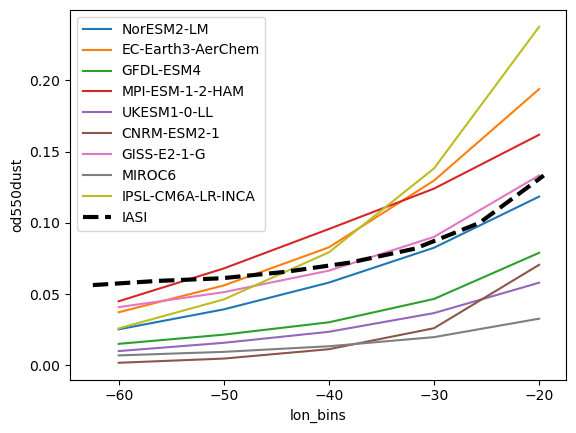

In [17]:
fig,ax = plt.subplots()
binned_model['RFMIP.NCC.NorESM2-LM.piClim-control.AERmon.gn'].isel(member_id=1)['od550dust'].mean(dim='time').plot(ax=ax, label='NorESM2-LM')
binned_model['RFMIP.EC-Earth-Consortium.EC-Earth3-AerChem.piClim-control.AERmon.gn'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='EC-Earth3-AerChem')
binned_model['AerChemMIP.NOAA-GFDL.GFDL-ESM4.piClim-control.AERmon.gr1'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='GFDL-ESM4')
binned_model['RFMIP.HAMMOZ-Consortium.MPI-ESM-1-2-HAM.piClim-control.AERmon.gn'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='MPI-ESM-1-2-HAM')
binned_model['AerChemMIP.MOHC.UKESM1-0-LL.piClim-control.AERmon.gn'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='UKESM1-0-LL')
binned_model['RFMIP.CNRM-CERFACS.CNRM-ESM2-1.piClim-control.AERmon.gr'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='CNRM-ESM2-1')
binned_model['RFMIP.NASA-GISS.GISS-E2-1-G.piClim-control.AERmon.gn'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='GISS-E2-1-G')
binned_model['RFMIP.MIROC.MIROC6.piClim-control.AERmon.gn'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='MIROC6')
binned_model['RFMIP.IPSL.IPSL-CM6A-LR-INCA.piClim-control.AERmon.gr'].isel(member_id=0)['od550dust'].mean(dim='time').plot(ax=ax, label='IPSL-CM6A-LR-INCA')
dod_binned['od550dust'].mean(dim='time').plot(ax=ax, color='black', linestyle='--', linewidth=3, label='IASI')
ax.legend()

In [18]:
binned_model['RFMIP.NCC.NorESM2-LM.piClim-control.AERmon.gn'] = binned_model['RFMIP.NCC.NorESM2-LM.piClim-control.AERmon.gn'].isel(member_id=1)

In [19]:
def get_struct_error(data_dict):
    """
    Calculate structural uncertainty as variance of the mean difference between North Atlantic and North Africa
    accross all models in data_dict
    """

    diffs = []
    for key in data_dict:
        diff = data_dict[key]['od550dust'].mean(dim='time')
        diff = diff.drop('wavelength', errors='ignore')
        if 'member_id' in diff.dims:
            diff_member = diff.isel(member_id=0)

        diffs.append(diff_member)
    da = xr.concat(diffs, dim='model')
    return da.std(dim='model')/np.sqrt(len(data_dict))

In [20]:
struct_err = get_struct_error(grad_model)

In [21]:
def get_internal_variability(data_dict):
    """
    Calculate internal variability of each model as the variance in time.
    """
    internal_variability = {}
    for key in data_dict:
        diff = data_dict[key]['od550dust']
        internal_variability[key]=diff.std(dim='time')

    return internal_variability


In [22]:
def calc_mod_implaus_table(mod_dict, obs_grad, struct_err,var_obs_grad, lon_bin=-30):
    """
    Calculate the implausibility of each model in mod_dict
    """
    nobs_years = len(obs_grad.time)
    obs_grad = obs_grad.sel(lon_bins=lon_bin).mean(dim='time')['od550dust'].values
    var_obs = var_obs_grad.sel(lon_bins=lon_bin).values**2
    var_mod_struct=struct_err.sel(lon_bins=lon_bin).values**2
    implausibility = {}
    for key in mod_dict:
        mod_grad = mod_dict[key]['od550dust'].sel(lon_bins=lon_bin).isel(member_id=0).mean(dim='time').values
        mod_interal_var = (mod_dict[key]['od550dust'].sel(lon_bins=lon_bin).isel(member_id=0).std(dim='time').values/np.sqrt(len(mod_dict[key].time)))**2
        implausibility[key.split('.')[2]] = calc_implausibility_obs(
            mod=mod_grad,
            obs=obs_grad,
            var_mod_struct=var_mod_struct,
            var_mod_internal=mod_interal_var,
            var_obs=var_obs,
            var_rep=0)
    return implausibility

In [23]:
internal_var = get_internal_variability(grad_model)

In [24]:
implaus_dict = calc_mod_implaus_table(grad_model, obs_grad, struct_err,var_obs_grad, lon_bin=-30)
implaus_df_30 = pd.DataFrame(implaus_dict, index=['implausibility_30']).T
implaus_dict = calc_mod_implaus_table(grad_model, obs_grad, struct_err,var_obs_grad, lon_bin=-40)
implaus_df_40 = pd.DataFrame(implaus_dict, index=['implausibility_40']).T
implaus_dict = calc_mod_implaus_table(grad_model, obs_grad, struct_err,var_obs_grad, lon_bin=-50)
implaus_df_50 = pd.DataFrame(implaus_dict, index=['implausibility_50']).T
implaus_dict = calc_mod_implaus_table(grad_model, obs_grad, struct_err,var_obs_grad, lon_bin=-60)
implaus_df_60 = pd.DataFrame(implaus_dict, index=['implausibility_60']).T

In [25]:
implaus_df_30.join(implaus_df_40).join(implaus_df_50).join(implaus_df_60)

,implausibility_30,implausibility_40,implausibility_50,implausibility_60
CNRM-ESM2-1,0.076271,0.419172,0.385318,0.215734
MPI-ESM-1-2-HAM,0.426421,2.550900,4.796754,4.766978
IPSL-CM6A-LR-INCA,5.091978,5.680861,5.492649,4.359570
MIROC6,1.978473,1.399851,0.812571,0.338722
UKESM1-0-LL,1.201086,0.459150,0.165427,0.541427
GFDL-ESM4,0.463088,0.084659,0.384119,0.718095
GISS-E2-1-G,0.467897,1.140517,1.820485,1.795053
NorESM2-LM,0.225997,1.727532,3.091955,2.941272
EC-Earth3-AerChem,2.694900,4.157527,4.477149,3.967205
